In [11]:
import io
import sys
from contextlib import redirect_stdout
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from shapely.geometry import Polygon
from shapely.geometry import Point
from datetime import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import pingouin as pg
import csv

# Alistamiento de datos para correlaciones

Se corre cuando se tiene una nueva base de datos para alistar el archivo, sólo se debe hacer una vez, y dicho archivo queda guardado, mostrandose en el siguiente bloque

<Axes: >

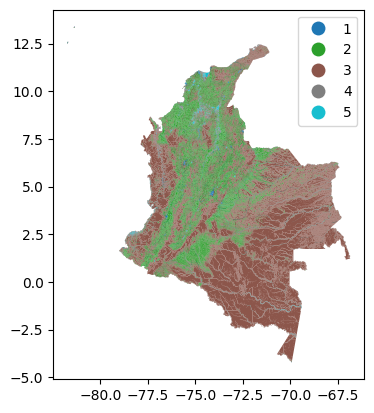

In [4]:
# Get the path to the file one directory up
# Get current working directory and go up one level
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
file_path = os.path.join(parent_dir, 'common/land_cover/e_cobertura_tierra_2020_admin.shp')


# Load the file into a GeoDataFrame
gdf = gpd.read_file(file_path)
dfg=gpd.read_file(file_path)#8\COBERTURAS CORINE 2018\shape coberturas 2018\cobertura_tierra_clc_2018.shp')
dfg.plot('nivel_1',legend=True)

In [8]:
dfg.columns

Index(['OBJECTID', 'codigo', 'leyenda', 'insumo', 'apoyo', 'confiabili',
       'cambio', 'nivel_1', 'nivel_2', 'nivel_3', 'nivel_4', 'nivel_5',
       'nivel_6', 'area_ha', 'nom_dpto', 'nom_mpio', 'Cod_dane_m', 'Categoria',
       'Cod_dane_d', 'cod_aa', 'nom_aa', 'SHAPE_Leng', 'SHAPE_Area',
       'geometry'],
      dtype='object')

In [9]:
mydict1={'1':'1. Territorios artificializados','2':'2. Territorios agrícolas','3':'3. Bosques y áreas seminaturales','4':'4. Áreas húmedas','5':'5. Superficies de agua'}
mydict1

{'1': '1. Territorios artificializados',
 '2': '2. Territorios agrícolas',
 '3': '3. Bosques y áreas seminaturales',
 '4': '4. Áreas húmedas',
 '5': '5. Superficies de agua'}

In [12]:
Nivel3_path = os.path.join(parent_dir, 'common/Nivel3.csv')
N3_path = os.path.join(parent_dir, 'common/N3.csv')

with open(Nivel3_path, mode='r') as infile:
    reader = csv.reader(infile)
    with open(N3_path, mode='w') as outfile:
        writer = csv.writer(outfile)
        mydict = {rows[1]:rows[0] for rows in reader}
mydict

{'111': '1.1.1. Tejido urbano continuo',
 '112': '1.1.2. Tejido urbano discontinuo',
 '121': '1.2.1. Zonas industriales o comerciales',
 '122': '1.2.2. Red vial, ferroviaria y terrenos asociados',
 '123': '1.2.3. Zonas portuarias',
 '124': '1.2.4. Aeropuertos',
 '125': '1.2.5. Obras hidráulicas',
 '131': '1.3.1. Zonas de extracción minera',
 '132': '1.3.2. Zona de disposición de residuos',
 '141': '1.4.1. Zonas verdes urbanas',
 '142': '1.4.2. Instalaciones recreativas',
 '211': '2.1.1. Otros cultivos transitorios',
 '212': '2.1.2. Cereales',
 '213': '2.1.3. Oleaginosas y leguminosas',
 '214': '2.1.4. Hortalizas',
 '215': '2.1.5. Tubérculos',
 '221': '2.2.1. Cultivos permanentes herbáceos',
 '222': '2.2.2. Cultivos permanentes arbustivos',
 '223': '2.2.3. Cultivos permanentes arbóreos',
 '224': '2.2.4. Cultivos agroforestales',
 '225': '2.2.5. Cultivos confinados',
 '231': '2.3.1. Pastos limpios',
 '232': '2.3.2. Pastos arbolados',
 '233': '2.3.3. Pastos enmalezados',
 '241': '2.4.1. M

In [13]:
dfg['Leyenda_1']=dfg['nivel_1'].map(mydict1)
dfg[['Leyenda_1','nivel_1']]

,Leyenda_1,nivel_1
0,3. Bosques y áreas seminaturales,3
1,3. Bosques y áreas seminaturales,3
2,3. Bosques y áreas seminaturales,3
3,3. Bosques y áreas seminaturales,3
4,3. Bosques y áreas seminaturales,3
...,...,...
393463,3. Bosques y áreas seminaturales,3
393464,3. Bosques y áreas seminaturales,3
393465,2. Territorios agrícolas,2
393466,2. Territorios agrícolas,2


In [14]:
dfg['Leyenda_3']=dfg['nivel_3'].map(mydict)
dfg[['Leyenda_3','nivel_3']]

,Leyenda_3,nivel_3
0,3.2.1. Herbazal,321
1,3.2.3. Vegetación secundaria o en transición,323
2,3.1.1. Bosque denso,311
3,3.2.3. Vegetación secundaria o en transición,323
4,3.1.1. Bosque denso,311
...,...,...
393463,3.1.1. Bosque denso,311
393464,3.1.1. Bosque denso,311
393465,2.3.1. Pastos limpios,231
393466,2.3.1. Pastos limpios,231


In [22]:
encoded_df = pd.get_dummies(dfg, columns=["Leyenda_3"])  # Encode the "leyenda 3" column
encoded_df1 = pd.get_dummies(dfg, columns=["Leyenda_1"])  # Encode the "Leyenda 1" column
#print(encoded_df1.columns)
encoded_df = pd.concat([encoded_df,encoded_df1[['Leyenda_1_1. Territorios artificializados', 'Leyenda_1_2. Territorios agrícolas', 'Leyenda_1_3. Bosques y áreas seminaturales','Leyenda_1_4. Áreas húmedas',
       'Leyenda_1_5. Superficies de agua']]], axis=1)
encoded_df['groupb']=0
encoded_df['geometry']

0         POLYGON ((-71.44167 6.81191, -71.44245 6.81107...
1         POLYGON ((-71.46141 6.79688, -71.46153 6.79663...
2         POLYGON ((-71.49475 6.79966, -71.49487 6.79961...
3         POLYGON ((-71.50173 6.79177, -71.50165 6.79156...
4         POLYGON ((-71.30257 6.84656, -71.30234 6.84679...
                                ...                        
393463    POLYGON ((-78.81297 1.49833, -78.81272 1.49810...
393464    POLYGON ((-78.85330 1.52076, -78.85423 1.52122...
393465    POLYGON ((-71.71523 4.51445, -71.71586 4.53488...
393466    POLYGON ((-71.55686 4.55962, -71.55697 4.55935...
393467    POLYGON ((-71.54726 4.57659, -71.54719 4.57608...
Name: geometry, Length: 393468, dtype: geometry

# Suplemental
Se debe correr la sección alistamiento de datos hastala línea donde se carga df_s y se muestra un mapa

In [23]:
encoded_df45 = encoded_df[(encoded_df['Leyenda_1_4. Áreas húmedas']>0)+(encoded_df['Leyenda_1_5. Superficies de agua']>0)]#tabla para eliminar el glint en la plataforma continental

In [24]:
encoded_df45

,OBJECTID,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,...,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua,groupb
217,218.0,512,"5.1.2. Lagunas, lagos y ciénagas naturales",Landsat_2020_mediana_07042021,NaN,SI,1,5,51,512,...,False,False,False,False,False,False,False,False,True,0
249,250.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,NaN,SI,1,4,41,411,...,False,False,False,False,False,False,False,True,False,0
255,256.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,NaN,SI,1,4,41,411,...,False,False,False,False,False,False,False,True,False,0
269,270.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,NaN,SI,2,4,41,411,...,False,False,False,False,False,False,False,True,False,0
338,339.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,NaN,SI,1,4,41,411,...,False,False,False,False,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393434,393435.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,False,False,False,False,False,False,False,True,False,0
393435,393436.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,False,False,False,False,False,False,False,True,False,0
393450,393451.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,False,False,False,False,False,False,False,True,False,0
393453,393454.0,511,5.1.1. Ríos,Landsat_2020_mediana_07042021,NaN,SI,1,5,51,511,...,False,False,False,False,False,False,False,False,True,0


In [25]:

satDataPath = os.path.join(parent_dir, 'common/colombia_result_corrected.csv')

df_s = pd.read_csv(satDataPath)

df_s

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12
...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28


In [26]:
df_s['coordinate_x'] = df_s['longitude'].apply(lambda x: [x])
df_s['coordinate_y'] = df_s['latitude'].apply(lambda x: [x])
df_s['coordinates'] = df_s['coordinate_x'] + df_s['coordinate_y']

delta_y = 0.01/2
delta_x = 0.01/2

df_s['geometry'] = df_s['coordinates'].apply(
    lambda x: Polygon([
        (x[0] - delta_x, x[1] - delta_y),
        (x[0] - delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] - delta_y)
    ]))

df_s

,id,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,geometry
0,20190208T164037_20190214T182526,-71.495,11.925,1549645332000,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]","POLYGON ((-71.5 11.92, -71.5 11.93000000000000..."
1,20190208T164037_20190214T182526,-71.745,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]","POLYGON ((-71.75 11.909999999999998, -71.75 11..."
2,20190208T164037_20190214T182526,-71.755,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]",POLYGON ((-71.75999999999999 11.90999999999999...
3,20190208T164037_20190214T182526,-71.765,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]","POLYGON ((-71.77 11.909999999999998, -71.77 11..."
4,20190208T164037_20190214T182526,-71.775,11.915,1549645332000,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]","POLYGON ((-71.78 11.909999999999998, -71.78 11..."
...,...,...,...,...,...,...,...,...,...,...
9121505,20241102T171753_20241104T094950,-72.435,4.525,1730569168000,1930.100098,2024-11-02 12:39:28,[-72.435],[4.525],"[-72.435, 4.525]","POLYGON ((-72.44 4.5200000000000005, -72.44 4...."
9121506,20241102T171753_20241104T094950,-72.445,4.525,1730569168000,1930.060781,2024-11-02 12:39:28,[-72.44500000000001],[4.525],"[-72.44500000000001, 4.525]","POLYGON ((-72.45 4.5200000000000005, -72.45 4...."
9121507,20241102T171753_20241104T094950,-72.455,4.525,1730569168000,1929.658248,2024-11-02 12:39:28,[-72.455],[4.525],"[-72.455, 4.525]","POLYGON ((-72.46 4.5200000000000005, -72.46 4...."
9121508,20241102T171753_20241104T094950,-72.255,4.525,1730569168000,1939.287932,2024-11-02 12:39:28,[-72.255],[4.525],"[-72.255, 4.525]",POLYGON ((-72.25999999999999 4.520000000000000...


In [27]:
l_in = list(encoded_df45.columns)

l_in



['OBJECTID',
 'codigo',
 'leyenda',
 'insumo',
 'apoyo',
 'confiabili',
 'cambio',
 'nivel_1',
 'nivel_2',
 'nivel_3',
 'nivel_4',
 'nivel_5',
 'nivel_6',
 'area_ha',
 'nom_dpto',
 'nom_mpio',
 'Cod_dane_m',
 'Categoria',
 'Cod_dane_d',
 'cod_aa',
 'nom_aa',
 'SHAPE_Leng',
 'SHAPE_Area',
 'geometry',
 'Leyenda_1',
 'Leyenda_3_1.1.1. Tejido urbano continuo',
 'Leyenda_3_1.1.2. Tejido urbano discontinuo',
 'Leyenda_3_1.2.1. Zonas industriales o comerciales',
 'Leyenda_3_1.2.2. Red vial, ferroviaria y terrenos asociados',
 'Leyenda_3_1.2.3. Zonas portuarias',
 'Leyenda_3_1.2.4. Aeropuertos',
 'Leyenda_3_1.2.5. Obras hidráulicas',
 'Leyenda_3_1.3.1. Zonas de extracción minera',
 'Leyenda_3_1.3.2. Zona de disposición de residuos',
 'Leyenda_3_1.4.1. Zonas verdes urbanas',
 'Leyenda_3_1.4.2. Instalaciones recreativas',
 'Leyenda_3_2.1.1. Otros cultivos transitorios',
 'Leyenda_3_2.1.2. Cereales',
 'Leyenda_3_2.1.3. Oleaginosas y leguminosas',
 'Leyenda_3_2.1.4. Hortalizas',
 'Leyenda_3_2.1.5

In [28]:
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)


l_in.remove('groupb')

l_in

['Leyenda_3_1.1.1. Tejido urbano continuo',
 'Leyenda_3_1.1.2. Tejido urbano discontinuo',
 'Leyenda_3_1.2.1. Zonas industriales o comerciales',
 'Leyenda_3_1.2.2. Red vial, ferroviaria y terrenos asociados',
 'Leyenda_3_1.2.3. Zonas portuarias',
 'Leyenda_3_1.2.4. Aeropuertos',
 'Leyenda_3_1.2.5. Obras hidráulicas',
 'Leyenda_3_1.3.1. Zonas de extracción minera',
 'Leyenda_3_1.3.2. Zona de disposición de residuos',
 'Leyenda_3_1.4.1. Zonas verdes urbanas',
 'Leyenda_3_1.4.2. Instalaciones recreativas',
 'Leyenda_3_2.1.1. Otros cultivos transitorios',
 'Leyenda_3_2.1.2. Cereales',
 'Leyenda_3_2.1.3. Oleaginosas y leguminosas',
 'Leyenda_3_2.1.4. Hortalizas',
 'Leyenda_3_2.1.5. Tubérculos',
 'Leyenda_3_2.2.1. Cultivos permanentes herbáceos',
 'Leyenda_3_2.2.2. Cultivos permanentes arbustivos',
 'Leyenda_3_2.2.3. Cultivos permanentes arbóreos',
 'Leyenda_3_2.2.4. Cultivos agroforestales',
 'Leyenda_3_2.2.5. Cultivos confinados',
 'Leyenda_3_2.3.1. Pastos limpios',
 'Leyenda_3_2.3.2. Past

In [30]:
for i in l_in:
    encoded_df45.loc[:, i] = encoded_df[i] * encoded_df['SHAPE_Area']

encoded_df45

,OBJECTID,codigo,leyenda,insumo,apoyo,confiabili,cambio,nivel_1,nivel_2,nivel_3,...,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua,groupb
217,218.0,512,"5.1.2. Lagunas, lagos y ciénagas naturales",Landsat_2020_mediana_07042021,NaN,SI,1,5,51,512,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000020,0
249,250.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,NaN,SI,1,4,41,411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000027,0.000000,0
255,256.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,NaN,SI,1,4,41,411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000098,0.000000,0
269,270.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,NaN,SI,2,4,41,411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000039,0.000000,0
338,339.0,411,4.1.1. Zonas pantanosas,Landsat_2020_mediana_07042021,NaN,SI,1,4,41,411,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000023,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393434,393435.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000088,0.000000,0
393435,393436.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000623,0.000000,0
393450,393451.0,421,4.2.1. Pantanos costeros,Landsat_2020_mediana_07042021,s2a_17nqb_201028.img,SI,4,4,42,421,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000053,0.000000,0
393453,393454.0,511,5.1.1. Ríos,Landsat_2020_mediana_07042021,NaN,SI,1,5,51,511,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000327,0


In [31]:
# for j in df_s.index:
#     #print(j)
#     f=encoded_df45[df_s['geometry'][j].intersects(encoded_df45['geometry'])]
#     f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
#     if not len(f1)==0:
#       for i in l_in:
#         df_s.loc[j, i]=f1[i].iloc[0].copy()
#     if j%5e4==0:
#       print(j)
# listind=[]
# for j in encoded_df45.index:
#     f = df_s[encoded_df45['geometry'][j].intersects(df_s['geometry'])]
#     #f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
#     listind.append(f.index)
# df_sfil=df_s[~listind]
# df_sfil.to_csv('colombia_results_filtrado.csv')


# #correr hasta acá


listind = []

for j in encoded_df45.index:
    f = df_s[encoded_df45['geometry'][j].intersects(df_s['geometry'])]
    listind.extend(f.index.tolist())  # Use extend instead of append to flatten the list


In [32]:

# Convert to unique indices
listind = list(set(listind))  # Remove duplicates if any

# Filter the dataframe
df_sfil = df_s[~df_s.index.isin(listind)]  # Use isin() for filtering
df_sfil.to_csv('colombia_results_filtrado.csv')

----------------------------------------------------